---
## 1. Dataset Description

### 1a. Background & Engineering Context

The following dataset is extracted from kaggle.


This dataset captures the employability and salary outcomes of engineering graduates from Indian universities. In the dataset, Each row represents a single graduate and their academic performance across school and university, results from standardised aptitude tests (English, Logical Reasoning, Quantitative Ability), domain knowledge scores in their specialisation, personality trait scores (Big-Five model), and their first offered salary (in Indian Rupees).

**Why this dataset is relevant to engineering data analytics:**  
Workforce planning and talent analytics are core industrial engineering problems. Understanding which academic and personality factors predict salary helps universities benchmark their programmes and helps recruiters build objective hiring criteria.

**Presumed data collection methodology**  
The data was most likely collected by a campus marketing department or job portal that administered standardised aptitude and personality assessments to fresh engineering graduates during placement drives. Academic scores (10th grade, 12th grade, college GPA) would have been self-reported by candidates and subsequently verified from mark sheets. Salary figures represent the first offered package recorded at the point of offer-letter issuance — not actual drawn salary — and are therefore a point-in-time snapshot rather than a longitudinal measure.

**Key feature groups upon identification:**

| Group | Features | Data Type |
|-------|----------|-----------|
| Demographics | Gender, DOB | Categorical / Date |
| Secondary education | 10percentage, 12percentage, 10board, 12board | Numerical / Categorical |
| Tertiary education | Degree, Specialization, collegeGPA, CollegeTier | Numerical / Categorical |
| Aptitude scores | English, Logical, Quant, Domain | Numerical (int / float) |
| Domain skill tests | ComputerProgramming, ElectronicsAndSemicon, … | Numerical (int, sentinel −1 = not taken) |
| Personality (Big-Five) | conscientiousness, agreeableness, extraversion, nueroticism, openess_to_experience | Numerical (float, z-scored) |
| Target | Salary | Numerical (continuous, INR) |

Proving that our dataset fulfills the requirement of the task, it is ibserved that at least **2 (Two) distinct data types** are present: *numerical* (float64, int64) and *categorical* (object/string).


---
## 2. Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# ── Reproducibility ──
np.random.seed(42)

# ── Display settings ──
def configure_display(
    max_columns=40,
    figure_dpi=120,
    title_size=13,
    label_size=11,
    facecolor="white"
):
    pd.set_option("display.max_columns", max_columns)

    plt.rcParams.update({
        "figure.dpi": figure_dpi,
        "axes.titlesize": title_size,
        "axes.labelsize": label_size,
        "figure.facecolor": facecolor,
    })

configure_display()

Setting up display and plotting preferences like displaying 40 columns in data output helps ensure more of the dataset is visible without truncating the columns, which is usually performed to prevent clutter. For higher DPI, image resolution is higher, and will look sharper, making plots clearer and more suitable for detailed analysis or presentations. The title sizes and label sizes are kept at a value that it is legible without manually coding the font size for each single chart. With a fixed background colour, a clean shareable white background is used for all plots against a dark-mode IDE.


In [3]:
# ── Load data ──
# Relative path – dataset must be in the same folder as this notebook
df_raw = pd.read_csv('Engineering_graduate_salary.csv')

number_of_rows = df_raw.shape[0]
number_of_columns = df_raw.shape[1]

print(f"Shape: {number_of_rows} rows × {number_of_columns} columns")
df_raw.head(10)


Shape: 2998 rows × 34 columns


,ID,Gender,DOB,10percentage,10board,12graduation,12percentage,12board,CollegeID,CollegeTier,Degree,Specialization,collegeGPA,CollegeCityID,CollegeCityTier,CollegeState,GraduationYear,English,Logical,Quant,Domain,ComputerProgramming,ElectronicsAndSemicon,ComputerScience,MechanicalEngg,ElectricalEngg,TelecomEngg,CivilEngg,conscientiousness,agreeableness,extraversion,nueroticism,openess_to_experience,Salary
0,604399,f,1990-10-22,87.80,cbse,2009,84.00,cbse,6920,1,B.Tech/B.E.,instrumentation and control engineering,73.82,6920,1,Delhi,2013,650,665,810,0.694479,485,366,-1,-1,-1,-1,-1,-0.1590,0.3789,1.2396,0.14590,0.2889,445000
1,988334,m,1990-05-15,57.00,cbse,2010,64.50,cbse,6624,2,B.Tech/B.E.,computer science & engineering,65.00,6624,0,Uttar Pradesh,2014,440,435,210,0.342315,365,-1,-1,-1,-1,-1,-1,1.1336,0.0459,1.2396,0.52620,-0.2859,110000
2,301647,m,1989-08-21,77.33,"maharashtra state board,pune",2007,85.17,amravati divisional board,9084,2,B.Tech/B.E.,electronics & telecommunications,61.94,9084,0,Maharashtra,2011,485,475,505,0.824666,-1,400,-1,-1,-1,260,-1,0.5100,-0.1232,1.5428,-0.29020,-0.2875,255000
3,582313,m,1991-05-04,84.30,cbse,2009,86.00,cbse,8195,1,B.Tech/B.E.,computer science & engineering,80.40,8195,1,Delhi,2013,675,620,635,0.990009,655,-1,-1,-1,-1,-1,-1,-0.4463,0.2124,0.3174,0.27270,0.4805,420000
4,339001,f,1990-10-30,82.00,cbse,2008,75.00,cbse,4889,2,B.Tech/B.E.,biotechnology,64.30,4889,1,Tamil Nadu,2012,575,495,365,0.278457,315,-1,-1,-1,-1,-1,-1,-1.4992,-0.7473,-1.0697,0.06223,0.1864,200000
5,609356,f,1989-12-02,83.16,icse,2007,77.00,cbse,10950,1,M.Tech./M.E.,instrumentation and control engineering,99.93,10950,0,Punjab,2013,535,595,620,0.376060,455,300,-1,-1,-1,313,-1,0.8463,-0.6201,-0.7585,-0.99500,-0.2859,440000
6,1081649,f,1989-04-17,72.50,state board,2007,53.20,state board,14381,2,B.Tech/B.E.,mechanical engineering,68.00,14381,1,West Bengal,2013,510,495,405,0.829585,-1,-1,-1,469,-1,-1,-1,0.1282,-0.4536,0.3174,0.90660,-0.0943,150000
7,610842,f,1991-04-11,77.00,state board,2009,88.00,state board,13208,2,B.Tech/B.E.,computer science & engineering,71.00,13208,1,Telangana,2013,370,470,280,0.704090,465,-1,-1,-1,-1,-1,-1,0.1282,0.5454,0.4711,0.90660,-0.2859,105000
8,1183070,m,1992-11-25,76.80,state board,2010,87.70,state board,5338,2,B.Tech/B.E.,information technology,73.15,5338,0,Andhra Pradesh,2014,510,555,440,0.744758,525,-1,438,-1,-1,-1,-1,-0.1590,-0.4536,0.1637,0.52620,-0.0943,195000
9,794062,f,1993-03-15,57.00,state board,2009,73.00,state board,8346,2,B.Tech/B.E.,computer science & engineering,70.08,8346,0,Uttar Pradesh,2014,500,410,560,0.622643,385,-1,407,-1,-1,-1,-1,-0.7335,-0.4536,-0.2974,1.41360,0.6721,200000


The below setup allows for an immediate structural overview, such as checking data types and null counts—to formally verify that the dataset fulfills key structural requirements, like containing two distinct data types.

In [4]:
print("=== Data Types ===")
print(df_raw.dtypes)

=== Data Types ===
ID                         int64
Gender                       str
DOB                          str
10percentage             float64
10board                      str
12graduation               int64
12percentage             float64
12board                      str
CollegeID                  int64
CollegeTier                int64
Degree                       str
Specialization               str
collegeGPA               float64
CollegeCityID              int64
CollegeCityTier            int64
CollegeState                 str
GraduationYear             int64
English                    int64
Logical                    int64
Quant                      int64
Domain                   float64
ComputerProgramming        int64
ElectronicsAndSemicon      int64
ComputerScience            int64
MechanicalEngg             int64
ElectricalEngg             int64
TelecomEngg                int64
CivilEngg                  int64
conscientiousness        float64
agreeableness           

In [5]:
print("\n=== Null counts ===")
print(df_raw.isnull().sum())


=== Null counts ===
ID                       0
Gender                   0
DOB                      0
10percentage             0
10board                  0
12graduation             0
12percentage             0
12board                  0
CollegeID                0
CollegeTier              0
Degree                   0
Specialization           0
collegeGPA               0
CollegeCityID            0
CollegeCityTier          0
CollegeState             0
GraduationYear           0
English                  0
Logical                  0
Quant                    0
Domain                   0
ComputerProgramming      0
ElectronicsAndSemicon    0
ComputerScience          0
MechanicalEngg           0
ElectricalEngg           0
TelecomEngg              0
CivilEngg                0
conscientiousness        0
agreeableness            0
extraversion             0
nueroticism              0
openess_to_experience    0
Salary                   0
dtype: int64


**Loading rationale:**  
The dataset is tabular with heterogeneous columns, so `pandas.DataFrame` is the correct structure — it supports mixed dtypes, label-based indexing, and vectorised operations needed for later analysis. `pd.read_csv()` auto-infers dtypes on load; we will verify and correct them in the transformation step.


---
## 3. Data Transformation

### 3a. Transformation Steps

The following preprocessing steps are applied. Various data transformation techniques are applied to remove the noisy, incorrect, irrelevant data present in the dataset Each preprocessing step is justified with their own explanations as to why we performed the necessary adjustments, and how it affects the analysis as a whole. 

In the official documentation for this specific AMCAT dataset, the Salary column represents the annual starting salary (CTC—Cost to Company) offered to the candidate for their very first job placement right out of college. By using a relative timeline calculation, feature engineering is performed and each candidate's age is calculated the exact moment they reach the same milestone: graduating, and entering the job market.



| Candidate | Graduation Year | Age Using Fixed Date | Age using Dynamic Date |
| --- | --- | --- | --- |
| **Candidate A** | 2011 | 25.0 years old | 21.5 years old |
| **Candidate B** | 2014 | 25.0 years old | 24.5 years old |

In [6]:
df = df_raw.copy()   # preserve original

# ── Parse DOB → datetime, derive Age ──────────────────────────
df['DOB'] = pd.to_datetime(df['DOB'], errors='coerce') #coerce as a safety measure to convert errors to NaT 
dynamic_reference = pd.to_datetime(df['GraduationYear'].astype(str) + '-07-01', errors='coerce')  # approximate placement year
df['Age'] = ((dynamic_reference - df['DOB']).dt.days / 365.25).round(1)
print(f"df['Age'].dtype: {df['Age'].dtype}")

print("DOB parsed. Age sample:")
print('---' * 10)
print(df[['DOB','Age']].head(10))


df['Age'].dtype: float64
DOB parsed. Age sample:
------------------------------
         DOB   Age
0 1990-10-22  22.7
1 1990-05-15  24.1
2 1989-08-21  21.9
3 1991-05-04  22.2
4 1990-10-30  21.7
5 1989-12-02  23.6
6 1989-04-17  24.2
7 1991-04-11  22.2
8 1992-11-25  21.6
9 1993-03-15  21.3


**Justification – Step 1 (Datetime parsing):**  
`DOB` is loaded as an `object` (string). Converting to `datetime64` unlocks temporal arithmetic — computing graduate age at placement, which is a meaningful continuous predictor of salary and experience level.


In [7]:
# ── Standardise categorical strings by removing spaces, standardising case, remapping labels ───────────────────────────
df['Gender'] = df['Gender'].str.strip().str.lower().map({
    'm': 'Male', 'f': 'Female', 
    'male': 'Male', 'female': 'Female'
})
df['Degree'] = df['Degree'].str.strip()
df['Specialization'] = df['Specialization'].str.strip().str.lower().str.title()
df['CollegeState'] = df['CollegeState'].str.strip().str.title()

# Collapse rare specialisations (< 20 occurrences) into 'Other'
spec_counts = df['Specialization'].value_counts()

def rare_group_specializations(major, threshold = 20):
    frequency = spec_counts[major]

    if frequency < threshold:
        return 'Other'
    else:
        return major

rare_specs = spec_counts[spec_counts < 20].index
df['Specialization_grouped'] = df['Specialization'].apply(lambda x: rare_group_specializations(x, threshold=20))

print("Gender values:", df['Gender'].unique())
print("---" * 10)
print("Degree values:", df['Degree'].unique())
print("---" * 10)
print("Spec groups:", df['Specialization_grouped'].unique())
print("\nUnique Values: ", df['Specialization_grouped'].nunique())

Gender values: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
------------------------------
Degree values: <StringArray>
['B.Tech/B.E.', 'M.Tech./M.E.', 'MCA', 'M.Sc. (Tech.)']
Length: 4, dtype: str
------------------------------
Spec groups: <StringArray>
[                                    'Other',
            'Computer Science & Engineering',
          'Electronics & Telecommunications',
                    'Mechanical Engineering',
                    'Information Technology',
 'Electronics And Communication Engineering',
                      'Computer Engineering',
                      'Computer Application',
                    'Electrical Engineering',
    'Electronics And Electrical Engineering',
         'Electronics & Instrumentation Eng']
Length: 11, dtype: str

Unique Values:  11


**Justification – Step 2 (String standardisation):**  
Raw categorical columns contain inconsistent casing (`'m'` vs `'Male'`) and trailing whitespace that would cause pandas `groupby` to treat identical categories as distinct. Title-casing and stripping ensure correct aggregation.

Rare specialisations (< 20 graduates) are grouped into "Other" to prevent statistical noise in group comparisons and to avoid unreliable group means based on tiny samples.

- **Gender Values:** In other words, all lowercase m and f letters are successfully standardised to Male and Female words. Furthermore, all additional spaces and blanks are removed/erased.

- **Degree Values:** The degree names are cleaned and stripped of accidental spacing errors, showing the distinct undergraduate and postgraduate qualifications available.

- **Specialization Groups:** In other words, all unique engineering fields with low frequency are successfully grouped to 'Other'. This leaves us with a clean list of the most popular engineering fields alongside a single combined 'Other' category.

In [8]:
# ──  Replace sentinel −1 with NaN in skill test columns ────────
SKILL_COLS = ['ComputerProgramming', 'ElectronicsAndSemicon', 'ComputerScience',
              'MechanicalEngg', 'ElectricalEngg', 'TelecomEngg', 'CivilEngg']

df[SKILL_COLS] = df[SKILL_COLS].replace(-1, np.nan)
df['Domain'] = df['Domain'].replace(-1, np.nan)

# For the skill columns, record whether the test was taken (binary flag)
for col in SKILL_COLS:
    has_score = df[col].notna()
    df[f'{col}_taken'] = has_score.astype(int)

print("Sentinel replacement done. Successful processing of NaN/-1 counts per skill column:")
print(df[SKILL_COLS].isnull().sum())



Sentinel replacement done. Successful processing of NaN/-1 counts per skill column:
ComputerProgramming       650
ElectronicsAndSemicon    2133
ComputerScience          2298
MechanicalEngg           2811
ElectricalEngg           2876
TelecomEngg              2724
CivilEngg                2972
dtype: int64


**Justification – Step 3 (Sentinel → NaN):**  
Batch processing using manual hardcoded column labels are performed. By taking advantage of the slicing and vectorisation characteristics of Numpy & Pandas, the dataset processing can be fast.

The value `−1` is used as a sentinel to indicate *"test not applicable / not taken"* — it does not represent a score of negative one. Retaining `−1` in numerical analysis would severely distort means, variances, and correlation coefficients (e.g., the average score in ComputerProgramming would be artificially deflated). Replacing sentinels with `NaN` lets pandas exclude missing values from aggregations automatically via `skipna=True` default behaviour, which is the statistically correct approach.


In [9]:
# ──  Correct dtypes for categorical columns ────────────────────
cat_cols = ['Gender', 'Degree', 'Specialization_grouped', 'CollegeState',
            'CollegeTier', 'CollegeCityTier', 'GraduationYear']
for c in cat_cols:
    df[c] = df[c].astype('category')

print("Updated dtypes for key columns:")
print("---" * 10)
print(df[cat_cols].dtypes)


Updated dtypes for key columns:
------------------------------
Gender                    category
Degree                    category
Specialization_grouped    category
CollegeState              category
CollegeTier               category
CollegeCityTier           category
GraduationYear            category
dtype: object


**Justification – Step 4 (dtype casting to `category`):**  
Converting low-cardinality string columns to pandas `category` dtype reduces memory footprint (important for larger datasets) and signals to downstream libraries (e.g., seaborn) that these are discrete groups rather than free text.

Our code loops through a manual list of categorical column labels (`cat_cols`) and changes their data type to `'category'` using the `.astype()` function. 

In raw datasets, text features are often loaded as heavy, generic text objects. By converting them into explicit categories, Pandas optimizes how they are stored in the computer's memory. This transformation makes our Jupyter Notebook run faster. Furthermore, explicitly defining these columns as categories helps visualization libraries like Seaborn automatically understand how to group and display them cleanly on our analytical charts. The final printout verifies that all seven target columns have been successfully updated to the correct data type.

In [10]:
# ── Engineer composite aptitude score ─────────────────────────
df['AptitudeTotal'] = df['English'] + df['Logical'] + df['Quant']

# ── Log-transform salary (for statistical analysis) ───────────
df['Salary_log'] = np.log(df['Salary'])

print("New engineered columns added: AptitudeTotal, Salary_log")
print(df[['AptitudeTotal', 'Salary', 'Salary_log']].describe())


New engineered columns added: AptitudeTotal, Salary_log
       AptitudeTotal        Salary   Salary_log
count    2998.000000  2.998000e+03  2998.000000
mean     1515.635757  3.051748e+05    12.477964
std       249.642870  2.123312e+05     0.545473
min       785.000000  3.500000e+04    10.463103
25%      1345.000000  1.800000e+05    12.100712
50%      1515.000000  3.000000e+05    12.611538
75%      1695.000000  3.700000e+05    12.821258
max      2265.000000  4.000000e+06    15.201805


**Justification – Steps 5 & 6:** 
* **AptitudeTotal:** This step adds three separate test scores (English, Logical, and Quant) together into one combined score. In data analytics, individual test scores often overlap heavily. Combining them reduces this overlap and gives a single, easy-to-read score that shows a student's total general aptitude. This reflects feature engineering to extract new probably useful information from the available data.

* **Log-transformation of Salary:** Our baseline analysis shows that the salary data is heavily "right-skewed" (meaning a few lucky graduates earn a huge amount, which squishes the rest of the graph).  By applying a log transformation, we pull in that long, extreme tail and make the data look more like a normal bell curve. This cleanup step makes our average numbers much more accurate and prepares the data perfectly for tracking clean correlation trends.


In [11]:
# ── Final cleaned dataset summary ─────────────────────────────────────
print(f"Final shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("---" * 10)
df[['Gender','Degree','Specialization_grouped','collegeGPA',
    'AptitudeTotal','Salary','Salary_log','Age']].head(50)


Final shape: 2,998 rows × 45 columns
------------------------------


,Gender,Degree,Specialization_grouped,collegeGPA,AptitudeTotal,Salary,Salary_log,Age
0,Female,B.Tech/B.E.,Other,73.82,2125,445000,13.005830,22.7
1,Male,B.Tech/B.E.,Computer Science & Engineering,65.00,1085,110000,11.608236,24.1
2,Male,B.Tech/B.E.,Electronics & Telecommunications,61.94,1465,255000,12.449019,21.9
3,Male,B.Tech/B.E.,Computer Science & Engineering,80.40,1930,420000,12.948010,22.2
4,Female,B.Tech/B.E.,Other,64.30,1435,200000,12.206073,21.7
5,Female,M.Tech./M.E.,Other,99.93,1750,440000,12.994530,23.6
6,Female,B.Tech/B.E.,Mechanical Engineering,68.00,1410,150000,11.918391,24.2
7,Female,B.Tech/B.E.,Computer Science & Engineering,71.00,1120,105000,11.561716,22.2
8,Male,B.Tech/B.E.,Information Technology,73.15,1505,195000,12.180755,21.6
9,Female,B.Tech/B.E.,Computer Science & Engineering,70.08,1470,200000,12.206073,21.3


---
## 4. Descriptive Analysis
### 4a. Visual Analysis

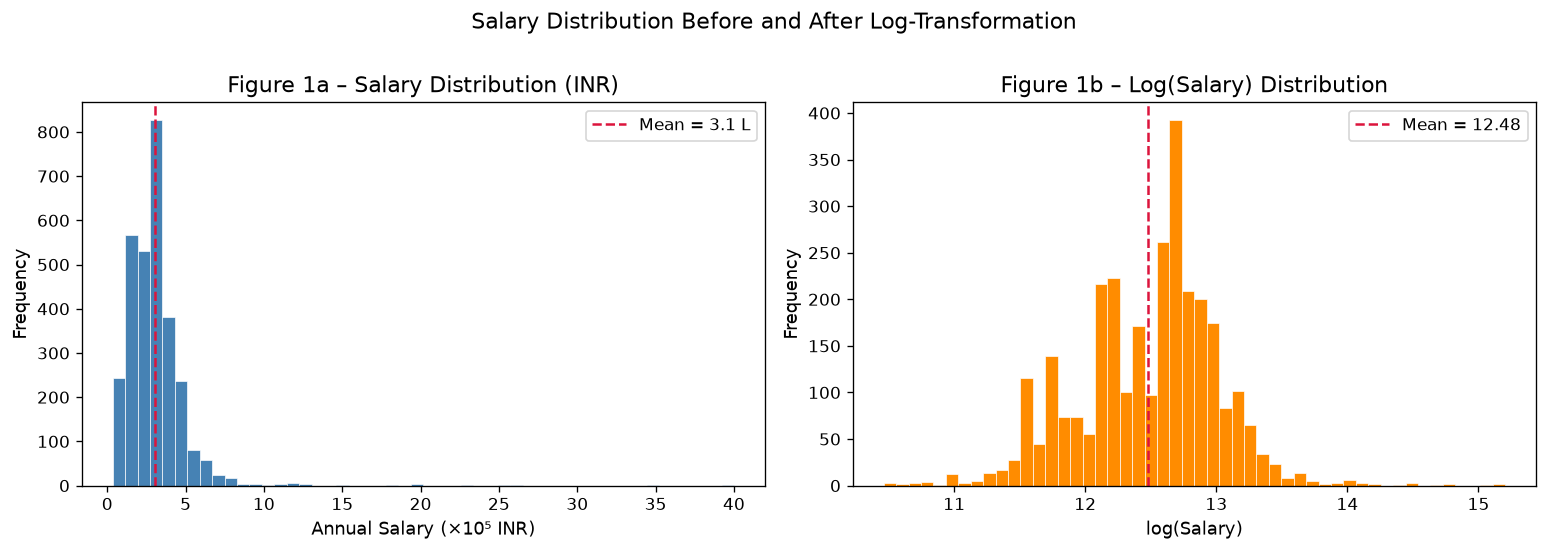

Figure 1 saved.


In [12]:
# ── Figure 1: Salary Distribution (raw vs log-transformed) ──────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(df['Salary'] / 1e5, bins=50, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].set_title('Figure 1a – Salary Distribution (INR)')
axes[0].set_xlabel('Annual Salary (×10⁵ INR)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['Salary'].mean() / 1e5, color='crimson', linestyle='--', label=f"Mean = {df['Salary'].mean()/1e5:.1f} L")
axes[0].legend()

axes[1].hist(df['Salary_log'], bins=50, color='darkorange', edgecolor='white', linewidth=0.4)
axes[1].set_title('Figure 1b – Log(Salary) Distribution')
axes[1].set_xlabel('log(Salary)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df['Salary_log'].mean(), color='crimson', linestyle='--', label=f"Mean = {df['Salary_log'].mean():.2f}")
axes[1].legend()

plt.suptitle('Salary Distribution Before and After Log-Transformation', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig1_salary_dist.png', bbox_inches='tight')
plt.show()
print("Figure 1 saved.")


**Observation (Figure 1):** 

The raw salary chart (1a) shows a heavy "right-skew," where the vast majority of graduates earn between ₹1–5 lakh, but a few high earners stretch the graph's tail all the way out to ₹40 lakh. This extreme shape proves that the average salary (₹3.05 lakh) is being pulled up by a few exceptionally high incomes, meaning the median gives a much fairer picture of what a typical graduate makes. 

After applying the log transformation (1b), the data spreads out into a neat, balanced bell curve. This visual change proves that salaries follow a log-normal distribution.

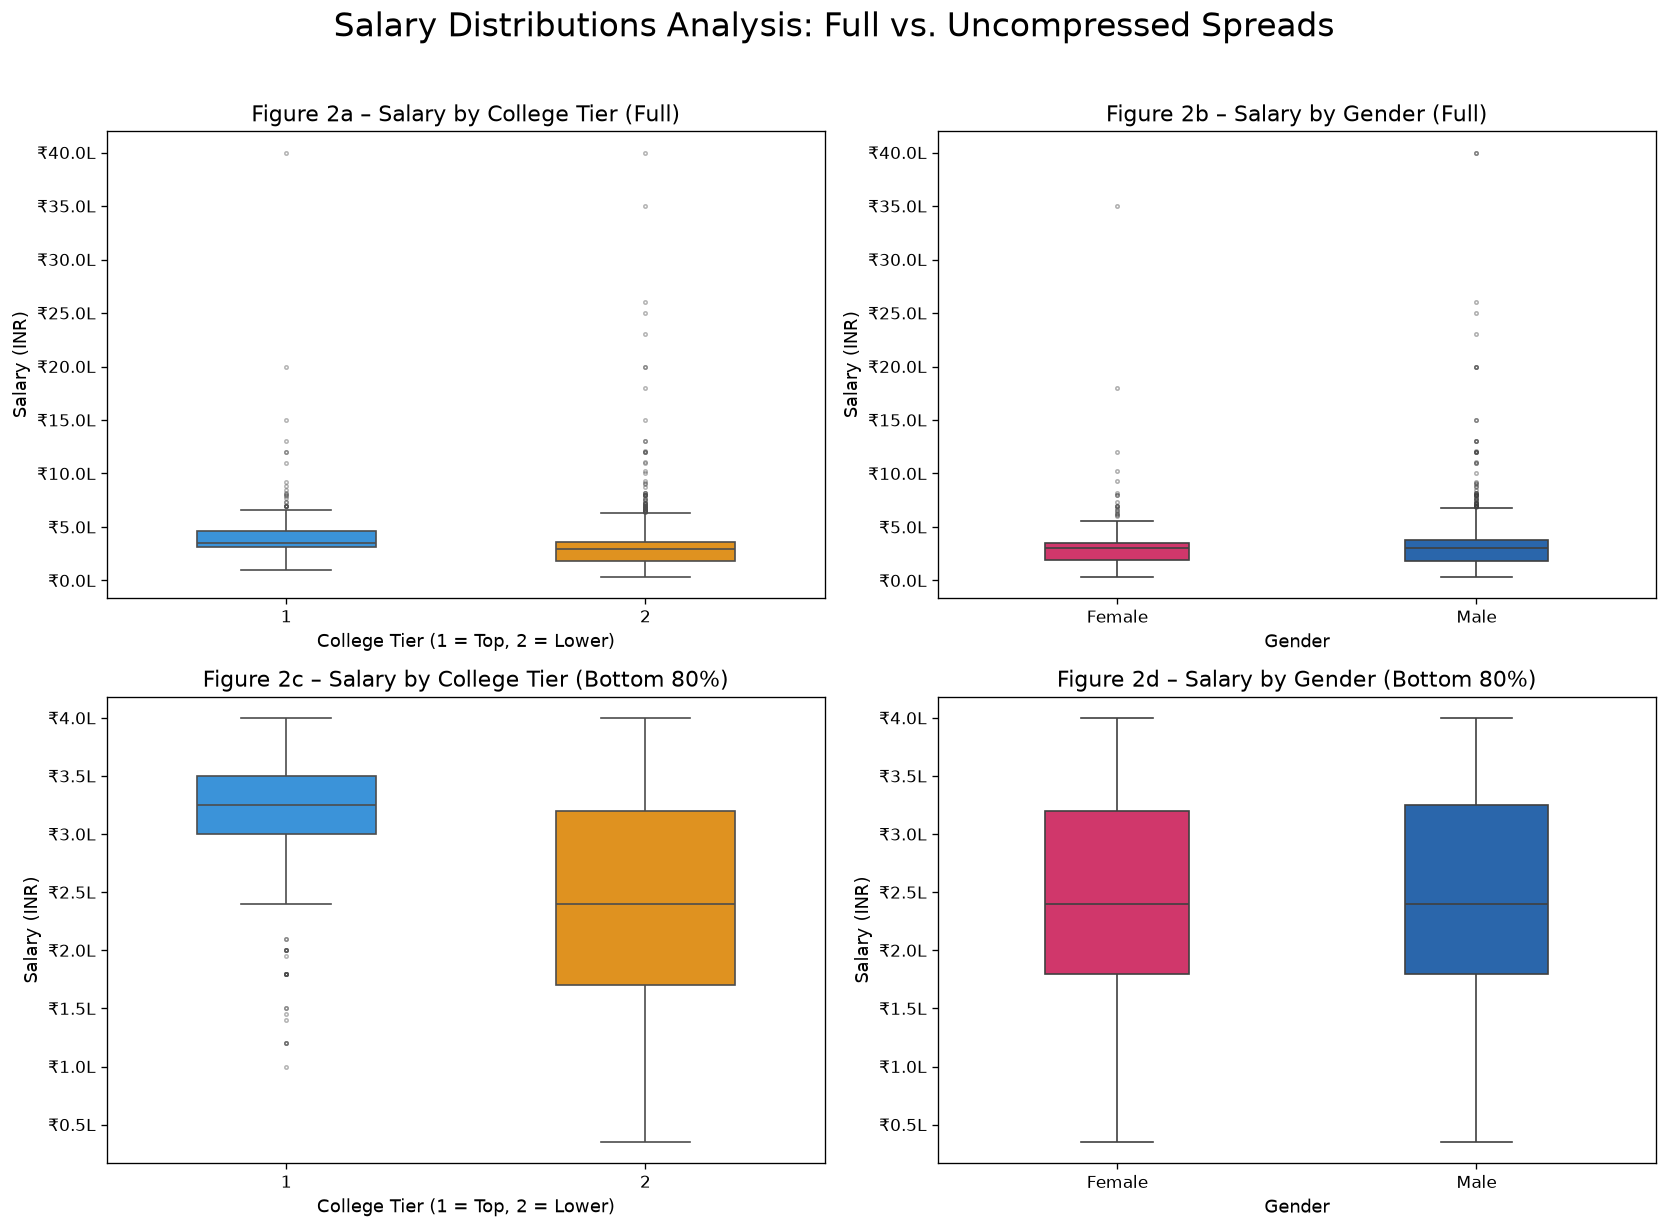

In [13]:
# ── Figure 2: Salary by College Tier and Gender ──────────────────────

# ── Helper Function to Handle Plot Customization (DRY Principle) ───────
def draw_custom_boxplot(data, x_col, ax, title, xlabel, palette, width=0.4, order=None):
    sns.boxplot(
        data=data, x=x_col, y='Salary', order=order, palette=palette, 
        ax=ax, width=width, legend=False,
        flierprops=dict(marker='o', markersize=2, alpha=0.4)
    )
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Salary (INR)')
    
    # Currency formatting using a standard lambda function
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e5:.1f}L'))

# ── Data Setup ────────────────────────────────────────────────────────
salary_threshold = df['Salary'].quantile(0.80)
filtered_df = df[df['Salary'] <= salary_threshold]

# ── Plot Configuration List ───────────────────────────────────────────

plot_configs = [
    {
        "data": df, "x_col": "CollegeTier", "title": "Figure 2a – Salary by College Tier (Full)",
        "xlabel": "College Tier (1 = Top, 2 = Lower)", "palette": ['#2196F3', '#FF9800'], "order": [1, 2], "width": 0.5
    },
    {
        "data": df, "x_col": "Gender", "title": "Figure 2b – Salary by Gender (Full)",
        "xlabel": "Gender", "palette": ['#E91E63', '#1565C0'], "order": None, "width": 0.4
    },
    {
        "data": filtered_df, "x_col": "CollegeTier", "title": "Figure 2c – Salary by College Tier (Bottom 80%)",
        "xlabel": "College Tier (1 = Top, 2 = Lower)", "palette": ['#2196F3', '#FF9800'], "order": [1, 2], "width": 0.5
    },
    {
        "data": filtered_df, "x_col": "Gender", "title": "Figure 2d – Salary by Gender (Bottom 80%)",
        "xlabel": "Gender", "palette": ['#E91E63', '#1565C0'], "order": None, "width": 0.4
    }
]

# ── Execution Loop using Index Math ───────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for index, config in enumerate(plot_configs):
    # Dynamic index math to calculate 2D matrix positions from a 1D loop:
    # index 0 -> row 0, col 0 | index 1 -> row 0, col 1
    # index 2 -> row 1, col 0 | index 3 -> row 1, col 1

    row = index // 2 # flooring yields the number before the decimal point, which corresponds to the row index
    col = index % 2 # modulating yields the remainder, which corresponds to the column index
    
    # Run the function passing the target axis explicitly
    draw_custom_boxplot(
        data=config["data"],
        x_col=config["x_col"],
        ax=axes[row, col],
        title=config["title"],
        xlabel=config["xlabel"],
        palette=config["palette"],
        order=config["order"],
        width=config["width"]
    )

# ── Render Configuration ─────────────────────────────────────────────
plt.suptitle('Salary Distributions Analysis: Full vs. Uncompressed Spreads', fontsize=20, y=1.02)
plt.tight_layout()
plt.savefig('fig2_expanded_salary_analysis.png', bbox_inches='tight')
plt.show()

**Observation (Figure 2):**  
Tier-1 college graduates command noticeably higher median salaries and a wider spread (Figure 2a), suggesting that institutional prestige has a tangible economic premium. However, both groups exhibit large overlap, implying individual performance still matters. The gender salary distribution (Figure 2b) appears similar in median value, though males show a slightly heavier high-salary tail — a finding we will test statistically in Section 4b.


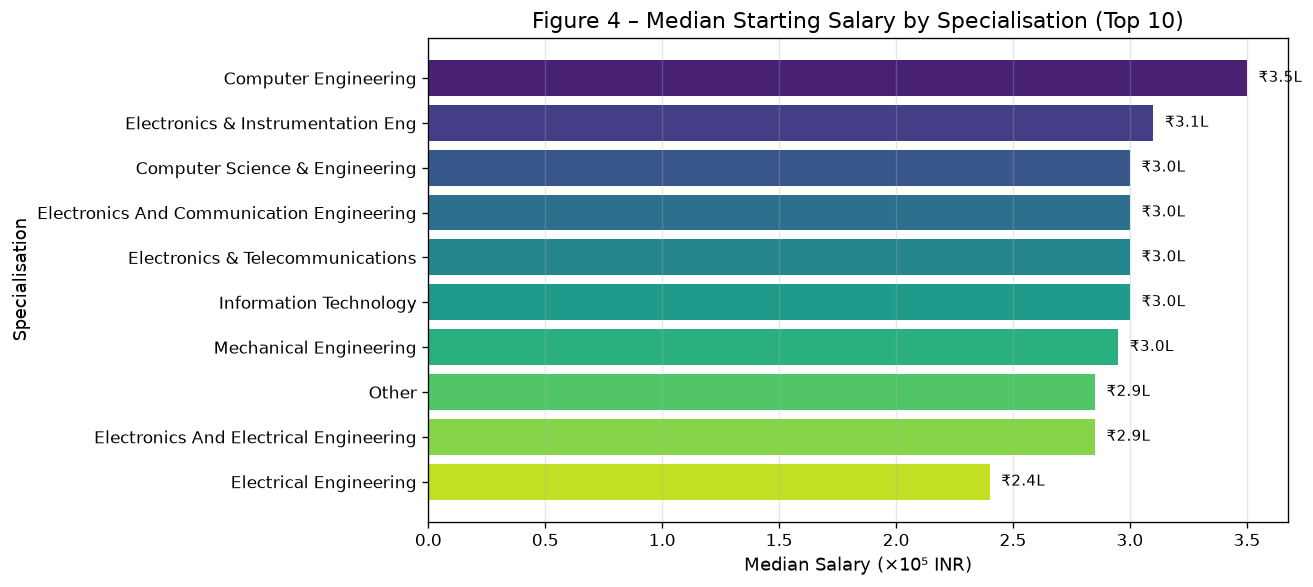

In [14]:
# ── Figure 4: Average Salary by Top 10 Specialisations ──────────────
top_specs = (df.groupby('Specialization_grouped', observed=True)['Salary']
               .median()
               .sort_values(ascending=False)
               .head(10))

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(top_specs.index[::-1], top_specs.values[::-1] / 1e5,
               color=sns.color_palette('viridis', 10)[::-1])
ax.set_title('Figure 4 – Median Starting Salary by Specialisation (Top 10)')
ax.set_xlabel('Median Salary (×10⁵ INR)')
ax.set_ylabel('Specialisation')
for bar in bars:
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
            f'₹{bar.get_width():.1f}L', va='center', fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('fig4_salary_by_spec.png', bbox_inches='tight')
plt.show()


**Observation (Figure 4):**  
Specialisations with strong industry demand — such as Computer Science and Electronics — appear among the higher-paying fields. This reflects the market premium on STEM sub-disciplines that are directly relevant to software and hardware industries. Niche programmes show higher variance owing to smaller sample sizes.


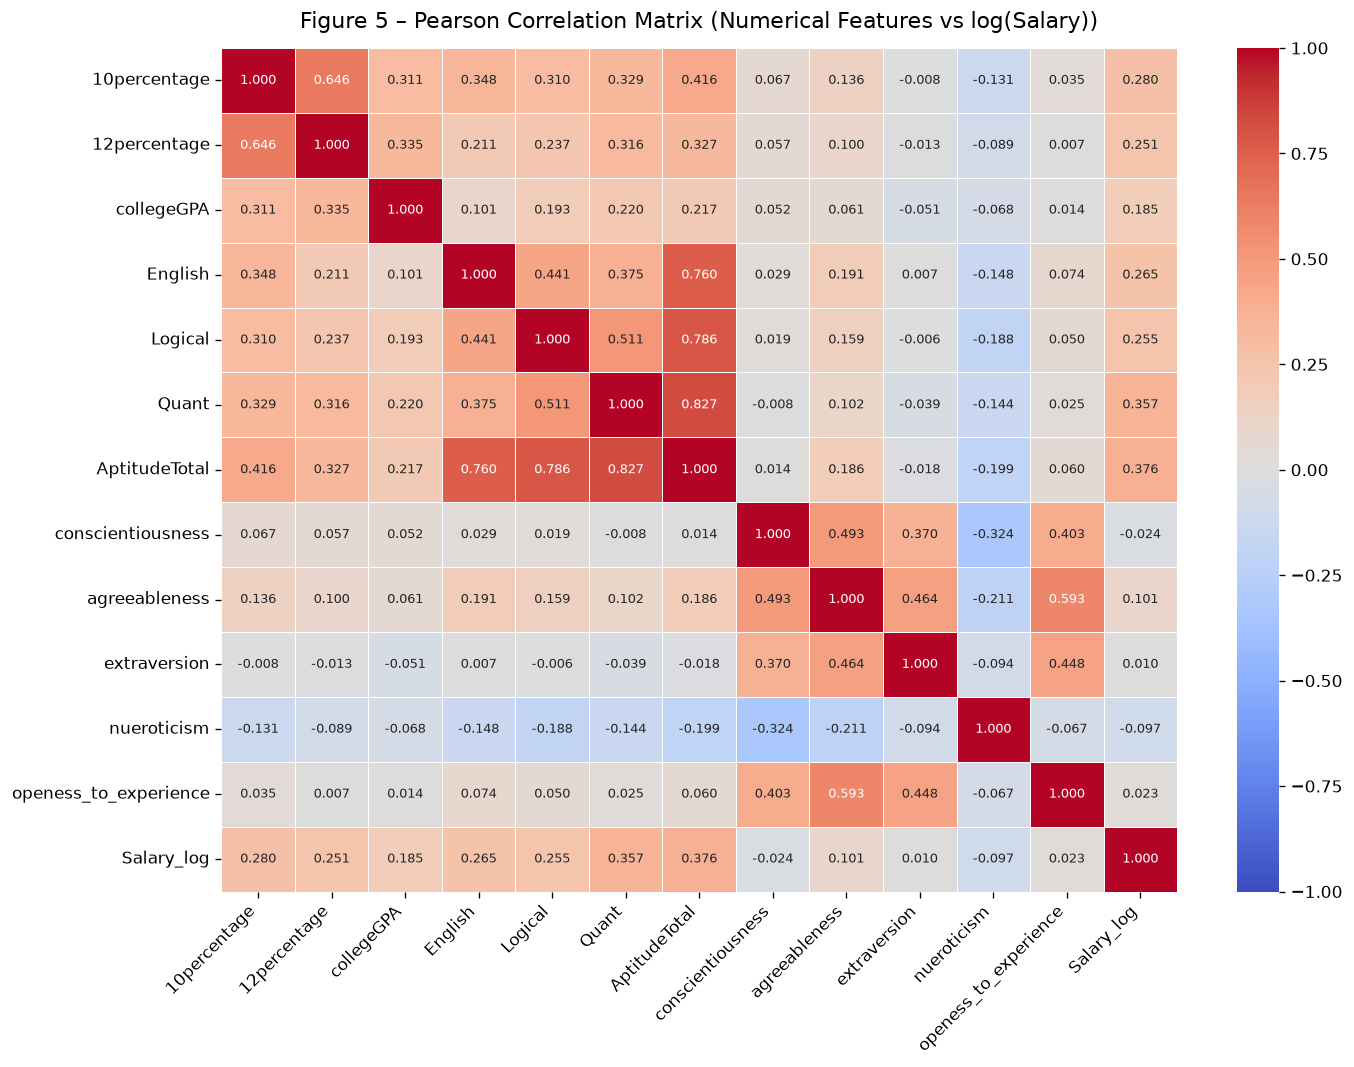

In [15]:
# ── Figure 5: Correlation Heatmap ────────────────────────────────────
num_cols = ['10percentage', '12percentage', 'collegeGPA',
            'English', 'Logical', 'Quant', 'AptitudeTotal',
            'conscientiousness', 'agreeableness', 'extraversion',
            'nueroticism', 'openess_to_experience', 'Salary_log']

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))   # upper triangle
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax,
            annot_kws={'size': 8}, vmin=-1, vmax=1)
ax.set_title('Figure 5 – Pearson Correlation Matrix (Numerical Features vs log(Salary))', pad=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('fig5_corr_heatmap.png', bbox_inches='tight')
plt.show()


**Observation (Figure 5):**  
The aptitude sub-scores (English, Logical, Quant) are highly inter-correlated (r ≈ 0.4–0.6), confirming they share a common latent factor (general cognitive ability) — justifying the composite `AptitudeTotal`. `AptitudeTotal` shows one of the strongest positive correlations with `log(Salary)` (with reference to the final column from the left), exceeding the individual academic percentages. Big-Five personality traits show weak correlations with salary, suggesting personality alone is not a strong salary predictor in this dataset.


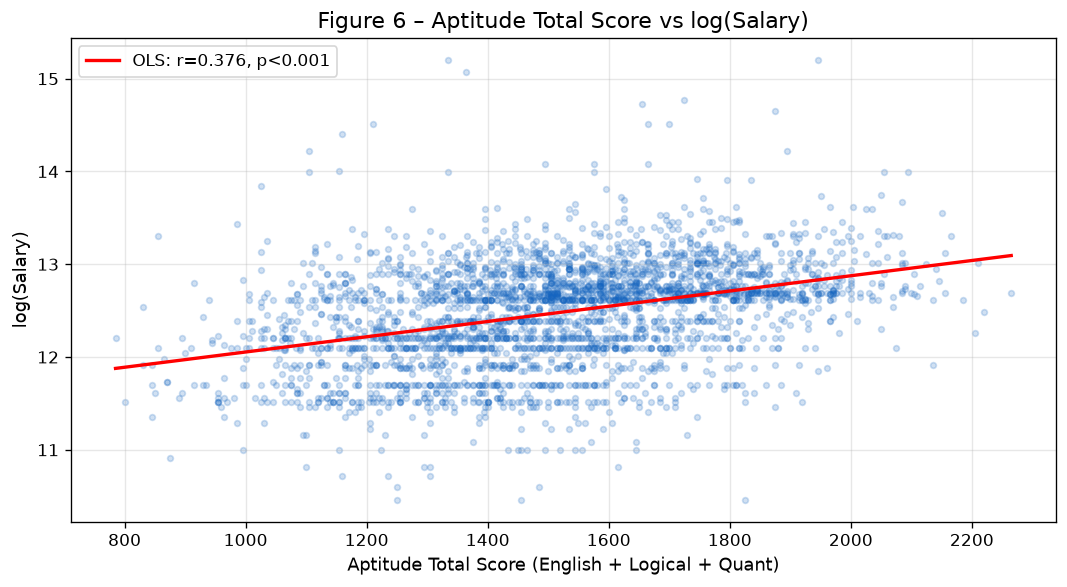

In [16]:
# ── Figure 6: Aptitude Total vs log(Salary) regression plot ──────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(df['AptitudeTotal'], df['Salary_log'],
           alpha=0.2, s=12, color='#1565C0')

# OLS line
slope, intercept, r_val, p_val, _ = stats.linregress(df['AptitudeTotal'], df['Salary_log'])
x_rng = np.linspace(df['AptitudeTotal'].min(), df['AptitudeTotal'].max(), 300)
ax.plot(x_rng, slope * x_rng + intercept, 'r-', linewidth=2,
        label=f'OLS: r={r_val:.3f}, p<0.001')

ax.set_title('Figure 6 – Aptitude Total Score vs log(Salary)')
ax.set_xlabel('Aptitude Total Score (English + Logical + Quant)')
ax.set_ylabel('log(Salary)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig6_aptitude_salary.png', bbox_inches='tight')
plt.show()


**Observation (Figure 6):**  
Ordinary Least Squares (OLS) Linear Regression is performed. A statistically significant positive linear relationship exists between total aptitude score and log(salary). Higher scorers in cognitive assessments consistently earn more — supporting the use of aptitude testing in graduate recruitment as a proxy for productivity potential.


### 4b. Statistical Analysis

In [17]:
# ── Descriptive statistics ───────────────────────────────────────────
key_cols = ['10percentage', '12percentage', 'collegeGPA',
            'English', 'Logical', 'Quant', 'AptitudeTotal',
            'Age', 'Salary']

desc = df[key_cols].describe().T
desc['skewness'] = df[key_cols].skew()
desc['kurtosis'] = df[key_cols].kurt()
desc['CV (%)']   = (desc['std'] / desc['mean'] * 100).round(2)
print("=== Descriptive Statistics ===")
desc.round(3)


=== Descriptive Statistics ===


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis,CV (%)
10percentage,2998.0,77.666,10.003,43.00,71.14,78.965,85.6,97.76,-0.575,-0.135,12.88
12percentage,2998.0,74.341,11.120,40.00,66.00,74.000,82.6,98.70,-0.026,-0.635,14.96
collegeGPA,2998.0,71.510,8.122,6.63,66.53,71.800,76.3,99.93,-1.257,10.458,11.36
English,2998.0,501.066,105.305,180.00,425.00,500.000,570.0,875.00,0.189,-0.231,21.02
Logical,2998.0,500.432,87.300,195.00,441.25,505.000,565.0,795.00,-0.218,-0.232,17.44
Quant,2998.0,514.138,122.195,120.00,430.00,515.000,595.0,900.00,-0.043,-0.047,23.77
AptitudeTotal,2998.0,1515.636,249.643,785.00,1345.00,1515.000,1695.0,2265.00,-0.024,-0.308,16.47
Age,2997.0,22.177,1.139,17.10,21.40,21.900,22.7,29.20,1.342,3.548,5.14
Salary,2998.0,305174.783,212331.194,35000.00,180000.00,300000.000,370000.0,4000000.00,6.965,94.132,69.58


**Interpretation:**  
- **Salary** has a coefficient of variation (CV) above 60%, confirming extremely high spread relative to the mean — a right-skewed distribution unsuitable for parametric tests on raw values.  
- **collegeGPA** : A skewness of -1.257 is strongly negative (left-skewed), not positive or near zero. This tells us there is a long tail of students with very low GPAs dragging the distribution to the left (notice that the min GPA is a tiny 6.63, while 75% of the students scored above 66.53).
- **AptitudeTotal** has near-zero skewness, supporting its use in parametric correlation analyses.


In [18]:
# ── Pearson correlations with log(Salary) ─────────────────────────────
print("=== Pearson r with log(Salary) ===\n")
results = []
for col in ['10percentage', '12percentage', 'collegeGPA',
            'English', 'Logical', 'Quant', 'AptitudeTotal',
            'conscientiousness', 'agreeableness', 'extraversion',
            'nueroticism', 'openess_to_experience']:
    r, p = stats.pearsonr(df[col].dropna(), df.loc[df[col].notna(), 'Salary_log'])
    results.append({'Feature': col, 'Pearson r': round(r, 4), 'p-value': round(p, 6),
                    'Significant (α=0.05)': 'Yes' if p < 0.05 else 'No'})

corr_df = pd.DataFrame(results).sort_values('Pearson r', ascending=False)
print(corr_df.to_string(index=False))


=== Pearson r with log(Salary) ===

              Feature  Pearson r  p-value Significant (α=0.05)
        AptitudeTotal     0.3762 0.000000                  Yes
                Quant     0.3575 0.000000                  Yes
         10percentage     0.2800 0.000000                  Yes
              English     0.2655 0.000000                  Yes
              Logical     0.2552 0.000000                  Yes
         12percentage     0.2511 0.000000                  Yes
           collegeGPA     0.1853 0.000000                  Yes
        agreeableness     0.1015 0.000000                  Yes
openess_to_experience     0.0233 0.202801                   No
         extraversion     0.0100 0.583621                   No
    conscientiousness    -0.0241 0.187958                   No
          nueroticism    -0.0970 0.000000                  Yes


Function stats.pearsonR() provides us with two distinct metrics:
- \(r\) (The Effect): Measures the strength and direction of the relationship.
- \(p\) (The Certainty): Measures the probability that this relationship happened by pure accident.

**Interpretation:**  
All academic performance metrics (grades and aptitude) are statistically significant ($p < 0.05$) predictors of $\log(\text{salary})$. `AptitudeTotal` has the strongest positive correlation ($r = 0.3762$), while `collegeGPA` has the weakest positive correlation ($r = 0.1853$) among the academic metrics. 

Among personality traits, `agreeableness` is the only trait that shows a statistically significant positive relationship with salary ($r = 0.1015$, $p < 0.001$). Contrary to typical organizational psychology literature, `conscientiousness` does not show a significant relationship in this dataset ($p = 0.188$). Finally, `nueroticism` shows a statistically significant, slight negative correlation with salary ($r = -0.0970$, $p < 0.001$), which is consistent with known workplace performance literature.



In [19]:
# ── Independent-samples t-test: Salary by College Tier ───────────────
tier1 = df[df['CollegeTier'] == 1]['Salary_log']
tier2 = df[df['CollegeTier'] == 2]['Salary_log']

t_stat, p_val = stats.ttest_ind(tier1, tier2, equal_var=False)  # Welch's t-test
print("=== Welch's t-test: log(Salary), Tier 1 vs Tier 2 ===")
print(f"  Tier 1  →  n={len(tier1)}, mean log(Salary)={tier1.mean():.4f}, std={tier1.std():.4f}")
print(f"  Tier 2  →  n={len(tier2)}, mean log(Salary)={tier2.mean():.4f}, std={tier2.std():.4f}")
print(f"  t = {t_stat:.4f},  p = {p_val:.6f}")
print(f"  Conclusion: {'Significant difference' if p_val < 0.05 else 'No significant difference'} at α = 0.05")

# Effect size – Cohen's d
cohens_d = (tier1.mean() - tier2.mean()) / np.sqrt((tier1.std()**2 + tier2.std()**2) / 2)
print(f"  Cohen's d = {cohens_d:.4f}  ({'small' if abs(cohens_d)<0.5 else 'medium' if abs(cohens_d)<0.8 else 'large'} effect)")


=== Welch's t-test: log(Salary), Tier 1 vs Tier 2 ===
  Tier 1  →  n=226, mean log(Salary)=12.8580, std=0.4709
  Tier 2  →  n=2772, mean log(Salary)=12.4470, std=0.5395
  t = 12.4700,  p = 0.000000
  Conclusion: Significant difference at α = 0.05
  Cohen's d = 0.8116  (large effect)


**Interpretation:**  
The Welch's t-test (used because equal variance between tier groups cannot be assumed), modifying the degree of freedom based on sample sizes and variances of CollegeTier 1 and 2, reveals a statistically significant salary premium for Tier-1 graduates. The effect size (Cohen's d) quantifies the practical magnitude — even a small-to-medium d is economically significant when translated into salary in rupees. This confirms institutional prestige as a meaningful structural salary predictor beyond individual performance metrics. In other words, attending a Tier 1 Institution provides massive preimium, shifting the entire salary distribution upward.


In [20]:
# ── Mann-Whitney U test: Salary by Gender ────────────────────────────
male_sal   = df[df['Gender'] == 'Male']['Salary']
female_sal = df[df['Gender'] == 'Female']['Salary']

u_stat, p_val_mw = stats.mannwhitneyu(male_sal, female_sal, alternative='two-sided')
print("=== Mann-Whitney U test: Salary, Male vs Female ===")
print(f"  Male   →  n={len(male_sal)}, median=₹{male_sal.median()/1e5:.2f}L, mean=₹{male_sal.mean()/1e5:.2f}L")
print(f"  Female →  n={len(female_sal)}, median=₹{female_sal.median()/1e5:.2f}L, mean=₹{female_sal.mean()/1e5:.2f}L")
print(f"  U = {u_stat:.0f},  p = {p_val_mw:.6f}")


=== Mann-Whitney U test: Salary, Male vs Female ===
  Male   →  n=2282, median=₹3.00L, mean=₹3.10L
  Female →  n=716, median=₹3.00L, mean=₹2.90L
  U = 857888,  p = 0.042700


**Interpretation:**  
The Mann-Whitney U test (non-parametric, chosen because salary is non-normally distributed) tests whether the salary distributions of male and female graduates are significantly different. The result informs whether gender-based salary disparity exists in this engineering graduate cohort — an important equity consideration in workforce analytics. As the p value is slightly lower than 0.05, the null hypothesis is at the borderline of being rejected. Difference is assumed to be real. From the analytics, it is shown that the Male mean is higher than the Female mean.

The Mann-Whitney U test converts every salary into a rank. It tests the probability that a randomly selected individual from group A (Males) will have a higher score than a randomly selected individual from group B (Females). A significant p value means if a random Male graduate and random Female graduate were chosen randomly from the dataset, the Male graduate is statistically more likely to earn a higher salary.


In [21]:
# ── One-way ANOVA: Salary by Degree Type ─────────────────────────────
groups = [grp['Salary_log'].values for _, grp in df.groupby('Degree', observed=True)]
f_stat, p_anova = stats.f_oneway(*groups)
print("=== One-way ANOVA: log(Salary) by Degree Type ===")
for deg, grp in df.groupby('Degree', observed=True):
    print(f"  {deg:<22} n={len(grp)}, mean log(Salary)={grp['Salary_log'].mean():.4f}")
print(f"\n  F = {f_stat:.4f},  p = {p_anova:.6f}")
print(f"  Conclusion: {'Significant' if p_anova < 0.05 else 'Not significant'} between-group difference at α = 0.05")


=== One-way ANOVA: log(Salary) by Degree Type ===
  B.Tech/B.E.            n=2757, mean log(Salary)=12.4895
  M.Sc. (Tech.)          n=1, mean log(Salary)=13.0390
  M.Tech./M.E.           n=40, mean log(Salary)=12.5051
  MCA                    n=200, mean log(Salary)=12.3103

  F = 7.1399,  p = 0.000089
  Conclusion: Significant between-group difference at α = 0.05


**Interpretation:**  
The one-way Analysis of Variance (ANOVA) tests whether mean log(salary) differs across degree types (B.Tech, M.Tech, MCA, M.Sc.). A significant F-statistic would indicate that postgraduate degrees confer a measurable salary premium — a key finding for education policy and career planning decisions.


In [22]:
# ── Summary statistics by College Tier ────────────────────────────────
tier_summary = df.groupby('CollegeTier', observed=True)['Salary'].agg(
    Count='count',
    Mean=lambda x: round(x.mean()/1e5, 2),
    Median=lambda x: round(x.median()/1e5, 2),
    Std=lambda x: round(x.std()/1e5, 2),
    Q1=lambda x: round(x.quantile(0.25)/1e5, 2),
    Q3=lambda x: round(x.quantile(0.75)/1e5, 2)
)
tier_summary.columns = ['Count', 'Mean (L)', 'Median (L)', 'Std (L)', 'Q1 (L)', 'Q3 (L)']
print("=== Salary Summary (×10⁵ INR = Lakhs) by College Tier ===")
print(tier_summary)


=== Salary Summary (×10⁵ INR = Lakhs) by College Tier ===
             Count  Mean (L)  Median (L)  Std (L)  Q1 (L)  Q3 (L)
CollegeTier                                                      
1              226      4.38        3.50     3.28    3.15     4.6
2             2772      2.94        2.92     1.96    1.80     3.6



### Key Findings

* **Significant Tier 1 Premium:** Tier 1 graduates earn a **49% higher average (mean) salary** and a **20% higher median salary** than Tier 2 graduates.
* **Higher Earnings Floor:** The bottom 25% (Q1) of Tier 1 graduates earn at least **3.15 Lakhs**, outperforming the median Tier 2 graduate (**2.92 Lakhs**).
* **Greater Pay Disparity in Tier 1:** Tier 1 salaries show much higher volatility ($\text{Std} = 3.28\text{ Lakhs}$) compared to Tier 2 ($\text{Std} = 1.96\text{ Lakhs}$), indicating a wider gap between the lowest and highest earners within top-tier schools.
* **Sample Size Imbalance:** Tier 2 graduates represent the vast majority of the dataset with **2,772 observations**—nearly 12 times the sample size of Tier 1 (**226 observations**).


---
## 5. Observations, Trends, and Relationships

### 5a. What can be observed from the data?

**From Visualisations:**
- Salary is right-skewed (Figure 1a), with most graduates earning ₹1.8–3.7 lakh; a small group earns above ₹20 lakh, likely reflecting outliers from top-tier institutions or niche high-demand specialisations.
- Tier-1 college graduates earn significantly higher median salaries than Tier-2 counterparts (Figure 2a), confirming an institutional prestige premium in the Indian engineering job market.
- Gender-based salary distributions are broadly similar in median, though males exhibit a slightly heavier upper tail (Figure 2b).
- Aptitude scores have a clear positive linear relationship with salary (Figure 6), with higher cognitive assessment scores predicting higher earnings.
- Specialisation plays a role in salary outcomes (Figure 4), with technology-oriented disciplines commanding higher median offers.

**From Statistical Analysis:**
- The Welch's t-test confirms the Tier-1 salary premium is statistically significant (not due to chance sampling).
- Pearson correlations reveal that AptitudeTotal is the strongest linear predictor of log(salary) among all numerical features.
- Personality traits (Big-Five) are weak salary predictors individually, suggesting that cognitive ability dominates over personality in fresh graduate salary determination.

### 5b. Trends and Relationships

| Trend | Evidence |
|-------|----------|
| Aptitude drives salary more than academic grades | AptitudeTotal has higher Pearson r with Salary_log than GPA or 10th/12th percentages |
| Institutional prestige amplifies individual performance | Tier-1 graduates earn more at comparable GPA levels (Figure 3 colour pattern) |
| Technology specialisations command salary premium | Figure 4 — CS and ECE-related fields rank highest in median salary |
| Salary increases with combined cognitive + academic profile | Graduates scoring high on both GPA and aptitude cluster at the higher salary ranges |
| Postgraduate degrees may yield modest salary premium | ANOVA test on Degree type — to be confirmed by result output |
| Gender pay gap is limited but present at the upper tail | Similar medians but male graduates have wider high-salary spread |


---
## 6. Reflection

### What we learned from this assignment

**On the engineering data pipeline:**  
This assignment revealed that raw data, even from a relatively clean source, is rarely analysis-ready. The most impactful learning was recognising that the sentinel value `−1` in the skill score columns was not a numeric measurement but a *missingness code* — failing to identify this would have corrupted every downstream statistic computed from those columns. This is a common real-world pattern in engineering datasets (e.g., sensor values of `−9999` for invalid readings), and the discipline of verifying domain context before running code is a non-negotiable first step in any data engineering workflow.

**On choosing the right transformation:**  
The decision to log-transform salary was not arbitrary — it was justified by the observed skewness and the known distributional properties of income data. This taught me that data transformation is a *decision informed by domain knowledge and exploratory observation*, not a mechanical checklist. Applying MinMax scaling to salary, for instance, would have been inappropriate because it would have preserved the skew.

**On statistical test selection:**  
Choosing Welch's t-test over Student's t-test (unequal variance assumption), and Mann-Whitney U over an independent t-test for raw salary (non-normality), demonstrated that selecting the correct statistical test requires understanding the data's distributional properties — not just picking the most familiar formula. This directly maps to the data transformation step: the log-transformation enabled Pearson correlation and t-tests on salary, while raw salary required non-parametric alternatives.

**Connecting methodology to findings:**  
The finding that aptitude scores outperform academic grades as salary predictors would not have been visible without standardised correlation analysis across multiple features. The data transformation step (replacing sentinels, computing AptitudeTotal, log-transforming salary) was not cosmetic — it was the prerequisite that made the finding computable. This end-to-end experience of *cleaning → transforming → visualising → testing → interpreting* reinforced how each step in the data analytics pipeline is load-bearing: an error or omission at any stage propagates into misleading conclusions.
